---
# **NFL Draft Prediction**
---



**Task:** Predict the probability that an NFL Combine participant is drafted  
**Primary metric:** ROC-AUC  
**Deliverable:** A validated `submission.csv` containing `Id` and `Drafted`


## **Notebook Goals**

1. Audit the competition data and establish validation assumptions.
2. Explore the target, missingness, numeric structure, and categorical cardinality.
3. Build domain-informed, target-independent features.
4. Compare multiple model families under identical stratified folds.
5. Evaluate out-of-fold discrimination, calibration, uncertainty, and errors.
6. Test conservative probability-averaging ensembles.
7. Refit the selected solution and generate a submission with automated checks.

> **Competition compliance.** This workflow uses only the provided files. It does not use external data, manual labels, or hand-edited predictions.

## **Table of contents**

1. [Environment and configuration](#1-environment-and-configuration)
2. [Data loading and integrity checks](#2-data-loading-and-integrity-checks)
3. [Exploratory data analysis](#3-exploratory-data-analysis)
4. [Feature engineering](#4-feature-engineering)
5. [Validation and model design](#5-validation-and-model-design)
6. [Cross-validated model comparison](#6-cross-validated-model-comparison)
7. [Ensembling and uncertainty](#7-ensembling-and-uncertainty)
8. [Diagnostics and interpretation](#8-diagnostics-and-interpretation)
9. [Final training and submission](#9-final-training-and-submission)
10. [Conclusions and next experiments](#10-conclusions-and-next-experiments)

### Source provenance and design improvements

The primary references for this notebook are the supplied GCI World competition materials: the competition README, baseline notebook, feature-addition tutorial, domain feature-engineering tutorial, hyperparameter-tuning tutorial, model-ensembling tutorial, and the three official CSV files.

This notebook consolidates those materials into one reproducible workflow and strengthens them with fold-local preprocessing, common cross-validation splits, out-of-fold diagnostics, calibration analysis, bootstrap uncertainty, subgroup error analysis, and automated submission checks.

## **1. Environment and Configuration** <a name="1-environment-and-configuration"></a>

All stochastic components share one seed. Learned preprocessing is fitted inside each cross-validation fold through scikit-learn pipelines. Row-wise feature formulas are created before cross-validation because they use neither the target nor population-level statistics.

In [ ]:
from pathlib import Path
from time import perf_counter
import json
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
N_SPLITS = 5
TARGET = "Drafted"
ID_COL = "Id"

np.random.seed(SEED)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titleweight": "bold", "figure.dpi": 120})

print(f"Python:       {platform.python_version()}")
print(f"pandas:       {pd.__version__}")
print(f"NumPy:        {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Random seed:  {SEED}")

Python:       3.13.15
pandas:       2.2.3
NumPy:        2.1.3
scikit-learn: 1.6.1
Random seed:  42


## **2. Data Loading and Integrity Checks** <a name="2-data-loading-and-integrity-checks"></a>

The path resolver supports a repository root, a notebook subdirectory, this executed artifact's workspace, and Google Colab-style layouts. For a clean repository, the recommended layout is:

```text
project/
├── input/
│   ├── train.csv
│   ├── test.csv
│   └── sample_submission.csv
├── nfl_draft_prediction.ipynb
└── outputs/
```

### 2.1 File Path Resolution and Loading

In [ ]:
def resolve_input_dir() -> Path:
    candidates = [
        Path("input"),
        Path("../input"),
        Path("drive_sources/input"),
        Path("/content/input"),
        Path("/content/drive/MyDrive/competition/input"),
        Path("/content/"),
    ]
    required = {"train.csv", "test.csv", "sample_submission.csv"}
    for candidate in candidates:
        if candidate.exists() and required.issubset({p.name for p in candidate.iterdir()}):
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate the three competition CSV files. Place them in an input/ directory."
    )


INPUT_DIR = resolve_input_dir()
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(INPUT_DIR / "train.csv")
test = pd.read_csv(INPUT_DIR / "test.csv")
sample_submission = pd.read_csv(INPUT_DIR / "sample_submission.csv")

print(f"Input directory: {INPUT_DIR}")
print(f"Train shape:     {train.shape}")
print(f"Test shape:      {test.shape}")
print(f"Submission:      {sample_submission.shape}")
display(train.head())

Input directory: /content
Train shape:     (2781, 16)
Test shape:      (696, 15)
Submission:      (696, 2)


,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0000,Lehigh,1.9050,140.1600,5.3900,59.6900,29.0000,251.4600,7.9100,4.9400,offense,offensive_lineman,OG,1.0000
1,1,2011,24.0000,Abilene Christian,1.8288,87.0897,4.3100,101.6000,16.0000,332.7400,NaN,NaN,offense,backs_receivers,WR,1.0000
2,2,2018,21.0000,Colorado St.,1.8542,92.9864,4.5100,91.4400,10.0000,309.8800,6.9500,4.3700,offense,backs_receivers,WR,1.0000
3,3,2010,21.0000,East Carolina,1.9304,148.7783,5.0900,76.2000,39.0000,254.0000,8.1200,4.7100,defense,defensive_lineman,DT,1.0000
4,4,2016,21.0000,California,1.8796,92.0793,4.6400,78.7400,NaN,281.9400,7.1300,4.2000,offense,backs_receivers,WR,1.0000


### 2.2 Schema and Integrity Verification

In [ ]:
expected_train_only = {TARGET}
assert TARGET in train.columns and TARGET not in test.columns
assert ID_COL in train.columns and ID_COL in test.columns
assert set(train.columns) - set(test.columns) == expected_train_only
assert train[ID_COL].is_unique and test[ID_COL].is_unique
assert set(train[ID_COL]).isdisjoint(set(test[ID_COL]))
assert train[TARGET].notna().all()
assert set(train[TARGET].unique()).issubset({0, 1})
assert list(sample_submission.columns) == [ID_COL, TARGET]
assert len(sample_submission) == len(test)
assert sample_submission[ID_COL].tolist() == test[ID_COL].tolist()

duplicate_rows = int(train.duplicated().sum())
schema = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "missing_pct": train.isna().mean().mul(100),
    "unique": train.nunique(dropna=False),
})

print(f"Duplicate training rows: {duplicate_rows}")
print("All structural integrity checks passed.")
display(schema)

Duplicate training rows: 0
All structural integrity checks passed.


,dtype,missing,missing_pct,unique
Id,int64,0,0.0000,2781
Year,int64,0,0.0000,11
Age,float64,435,15.6419,10
School,object,0,0.0000,236
Height,float64,0,0.0000,18
Weight,float64,0,0.0000,188
Sprint_40yd,float64,145,5.2140,144
Vertical_Jump,float64,554,19.9209,55
Bench_Press_Reps,float64,721,25.9259,43
Broad_Jump,float64,581,20.8918,59


## **3. Exploratory Data Analysis** <a name="3-exploratory-data-analysis"></a>

The analysis focuses on evidence that can influence validation and modeling. The ID is excluded from learning. Missing values are treated as potentially informative rather than silently discarded.

### 3.1 Target Class Distribution

,count,percentage
Drafted,,
Drafted,1803,64.8328
Not drafted,978,35.1672


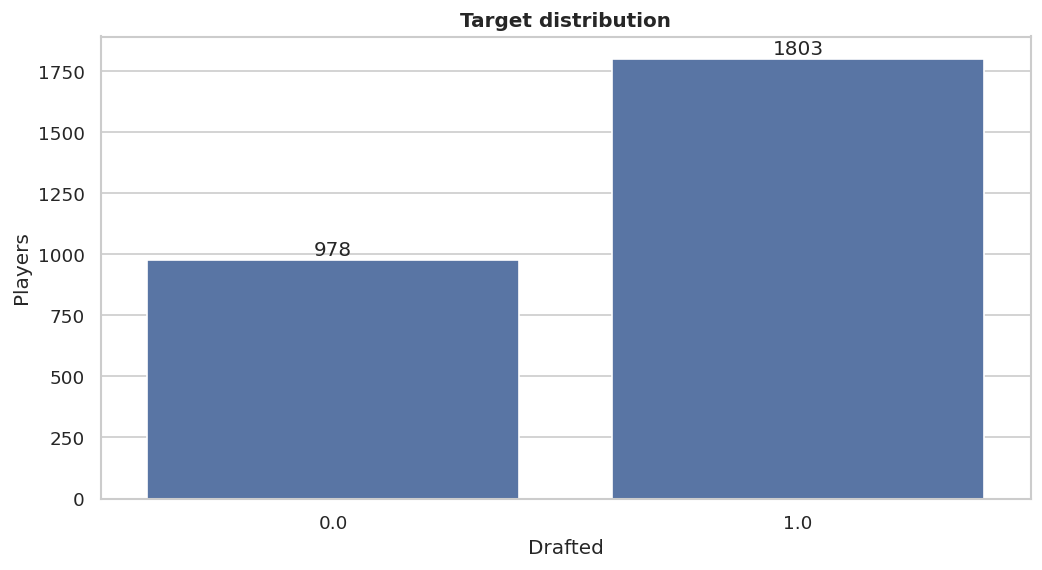

In [ ]:
target_summary = (
    train[TARGET]
    .value_counts()
    .rename(index={0: "Not drafted", 1: "Drafted"})
    .to_frame("count")
)
target_summary["percentage"] = target_summary["count"] / len(train) * 100
display(target_summary)

ax = sns.countplot(data=train, x=TARGET)
ax.set(title="Target distribution", xlabel="Drafted", ylabel="Players")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### 3.2 Missing Value Analysis

,missing,missing_rate
Agility_3cone,970.0000,34.8795
Shuttle,912.0000,32.7940
Bench_Press_Reps,721.0000,25.9259
Broad_Jump,581.0000,20.8918
Vertical_Jump,554.0000,19.9209
Age,435.0000,15.6419
Sprint_40yd,145.0000,5.2140


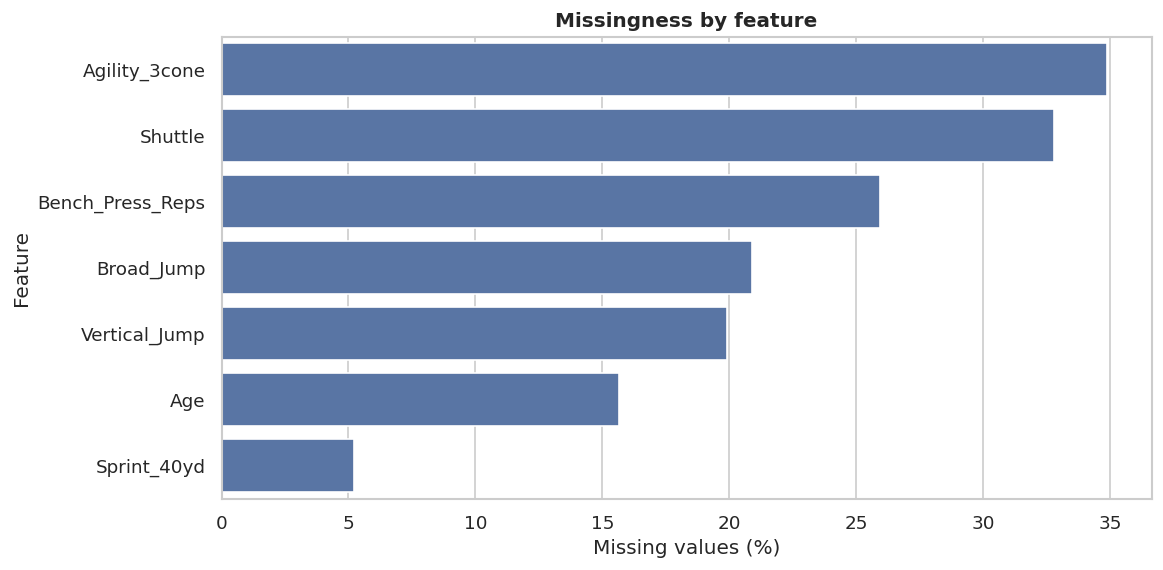

In [ ]:
missing_summary = (
    train.drop(columns=[TARGET])
    .isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missing", "mean": "missing_rate"})
    .query("missing > 0")
    .sort_values("missing_rate", ascending=False)
)
missing_summary["missing_rate"] *= 100
display(missing_summary)

ax = sns.barplot(
    data=missing_summary.reset_index(),
    x="missing_rate",
    y="index",
    color=sns.color_palette()[0],
)
ax.set(title="Missingness by feature", xlabel="Missing values (%)", ylabel="Feature")
plt.show()

### 3.3 Target-Missingness Correlation

In [ ]:
missing_target_rows = []
for feature in missing_summary.index:
    available_rate = train.loc[train[feature].notna(), TARGET].mean()
    missing_rate = train.loc[train[feature].isna(), TARGET].mean()
    missing_target_rows.append({
        "feature": feature,
        "draft_rate_when_available": available_rate,
        "draft_rate_when_missing": missing_rate,
        "absolute_gap": abs(available_rate - missing_rate),
    })

missing_target_analysis = (
    pd.DataFrame(missing_target_rows)
    .sort_values("absolute_gap", ascending=False)
    .reset_index(drop=True)
)
display(missing_target_analysis.style.format({
    "draft_rate_when_available": "{:.2%}",
    "draft_rate_when_missing": "{:.2%}",
    "absolute_gap": "{:.2%}",
}))

print(
    "Important validation note: a large missingness gap can be a legitimate data-generation signal, "
    "but it can also be unstable under distribution shift. It is retained and audited in the error analysis."
)

,feature,draft_rate_when_available,draft_rate_when_missing,absolute_gap
0,Age,76.51%,1.84%,74.67%
1,Vertical_Jump,66.41%,58.48%,7.93%
2,Shuttle,67.15%,60.09%,7.06%
3,Broad_Jump,66.27%,59.38%,6.89%
4,Agility_3cone,67.15%,60.52%,6.63%
5,Sprint_40yd,65.17%,58.62%,6.55%
6,Bench_Press_Reps,66.46%,60.19%,6.26%


Important validation note: a large missingness gap can be a legitimate data-generation signal, but it can also be unstable under distribution shift. It is retained and audited in the error analysis.


### 3.4 Feature Distributions and Correlations

,feature,unique_levels,most_frequent,top_frequency_pct
0,School,236,Alabama,2.6250
1,Player_Type,3,offense,51.9597
2,Position_Type,7,backs_receivers,36.3179
3,Position,20,WR,14.2035


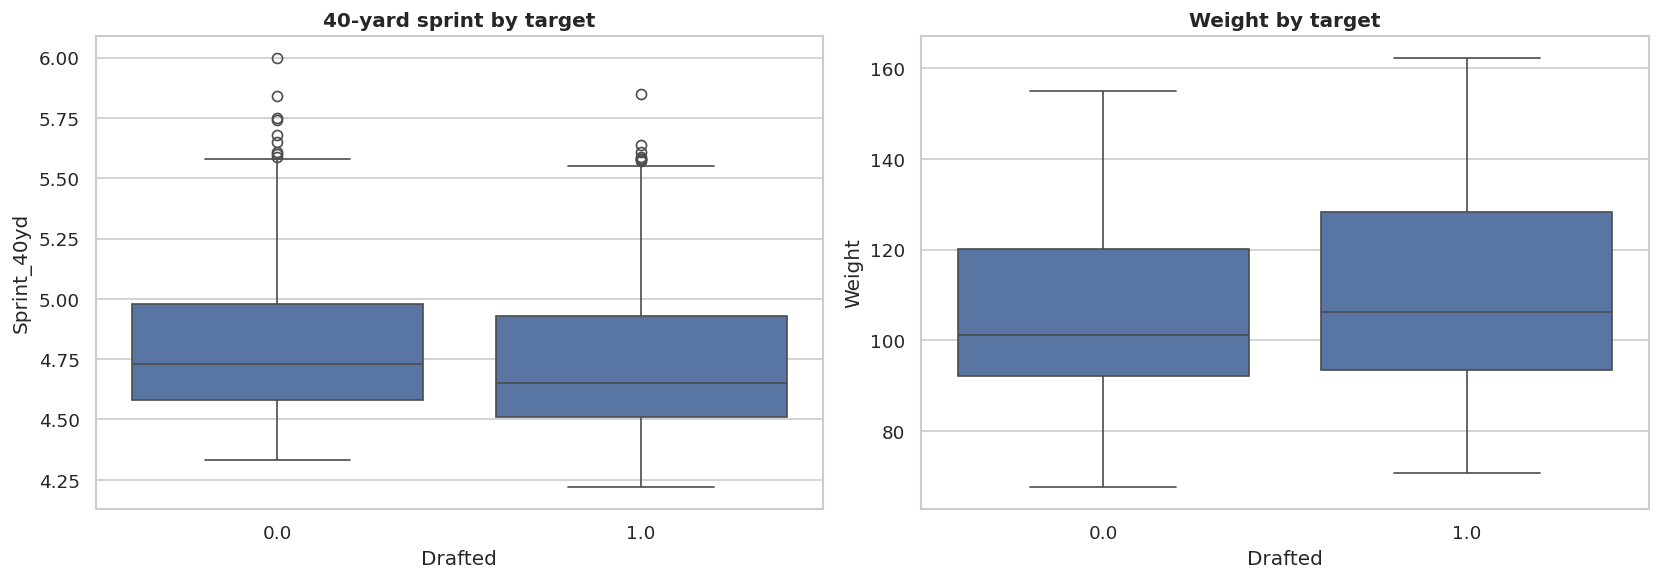

In [ ]:
categorical_cols_raw = train.drop(columns=[TARGET, ID_COL]).select_dtypes(include="object").columns.tolist()
numeric_cols_raw = train.drop(columns=[TARGET, ID_COL]).select_dtypes(exclude="object").columns.tolist()

categorical_summary = pd.DataFrame({
    "feature": categorical_cols_raw,
    "unique_levels": [train[c].nunique(dropna=False) for c in categorical_cols_raw],
    "most_frequent": [train[c].mode(dropna=False).iloc[0] for c in categorical_cols_raw],
    "top_frequency_pct": [train[c].value_counts(dropna=False, normalize=True).iloc[0] * 100 for c in categorical_cols_raw],
})
display(categorical_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=train, x=TARGET, y="Sprint_40yd", ax=axes[0])
axes[0].set_title("40-yard sprint by target")
sns.boxplot(data=train, x=TARGET, y="Weight", ax=axes[1])
axes[1].set_title("Weight by target")
plt.tight_layout()
plt.show()

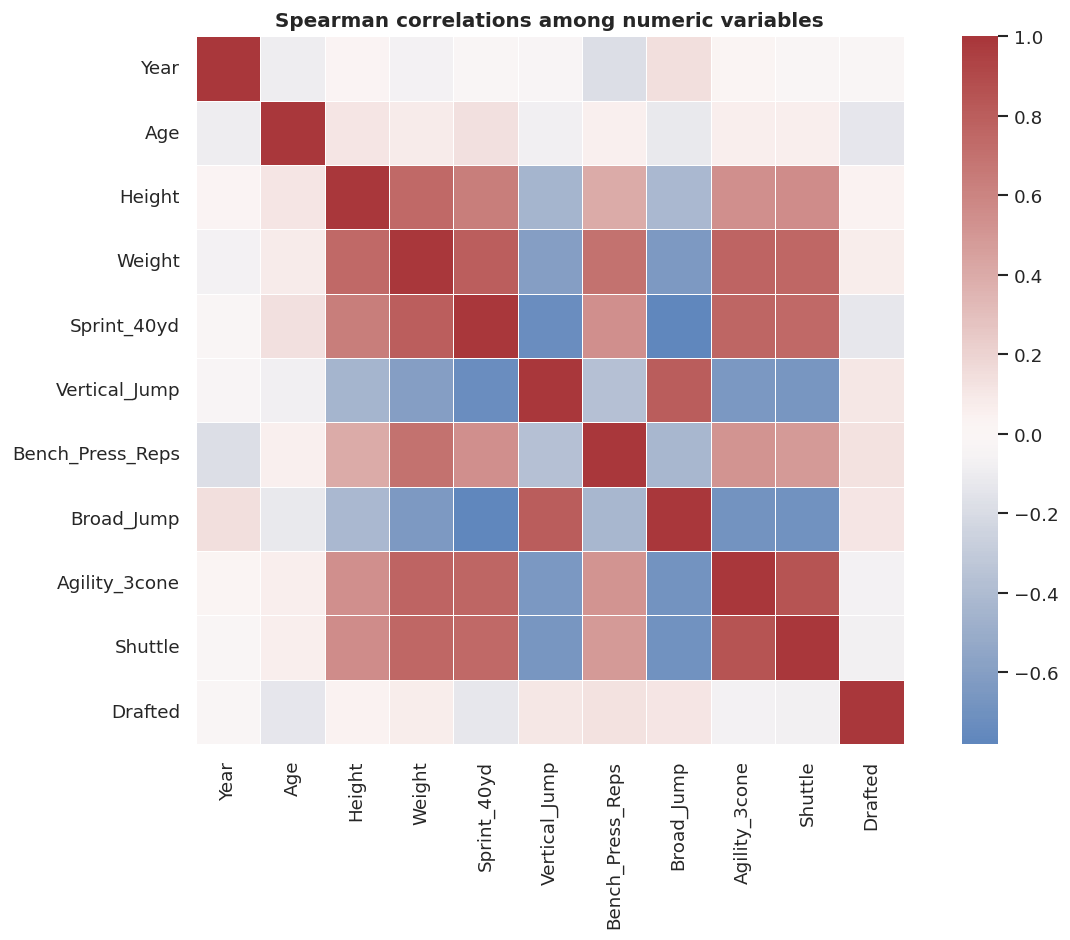

,spearman_correlation_with_target
Age,-0.1406
Sprint_40yd,-0.1302
Bench_Press_Reps,0.1279
Broad_Jump,0.1138
Vertical_Jump,0.1035
Shuttle,-0.0762
Weight,0.0737
Agility_3cone,-0.0676
Height,0.0445
Year,-0.0240


In [ ]:
numeric_for_corr = train[numeric_cols_raw + [TARGET]].copy()
corr = numeric_for_corr.corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="vlag", center=0, square=True, linewidths=0.3)
plt.title("Spearman correlations among numeric variables")
plt.tight_layout()
plt.show()

display(
    corr[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
    .rename("spearman_correlation_with_target")
    .to_frame()
)

## **4. Feature Engineering** <a name="4-feature-engineering"></a>

The features below are deterministic and domain-motivated:

- **BMI:** weight relative to squared height.
- **Speed score:** combines body mass and sprint time; faster times are rewarded nonlinearly.
- **Mass-height ratio:** a simple size proxy.
- **Tests completed:** summarizes measurement completeness.
- **Age missing:** explicitly preserves the strongest missingness pattern observed in EDA.

The imputer's missing indicators preserve missingness for every incomplete numeric feature. No target encoding or external lookup is used.

### 4.1 Domain Feature Engineering Logic

In [ ]:
MEASUREMENT_COLS = [
    "Age", "Sprint_40yd", "Vertical_Jump", "Bench_Press_Reps",
    "Broad_Jump", "Agility_3cone", "Shuttle"
]


def add_domain_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    eps = 1e-8
    out["BMI"] = out["Weight"] / (out["Height"].pow(2) + eps)
    out["SPEED_SCORE"] = out["Weight"] * 200 / (out["Sprint_40yd"].pow(4) + eps)
    out["MASS_HEIGHT_RATIO"] = out["Weight"] / (out["Height"] + eps)
    out["TESTS_COMPLETED"] = out[MEASUREMENT_COLS].notna().sum(axis=1)
    out["AGE_MISSING"] = out["Age"].isna().astype("int8")
    return out


X = add_domain_features(train.drop(columns=[TARGET, ID_COL]))
y = train[TARGET].astype(int)
X_test = add_domain_features(test.drop(columns=[ID_COL]))

assert X.columns.tolist() == X_test.columns.tolist()
assert np.isfinite(X.select_dtypes(exclude="object").dropna().to_numpy()).all()

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

print(f"Modeling matrix: {X.shape}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print("Engineered features:", [c for c in X.columns if c not in train.columns])

Modeling matrix: (2781, 19)
Numeric features: 15
Categorical features: 4
Engineered features: ['BMI', 'SPEED_SCORE', 'MASS_HEIGHT_RATIO', 'TESTS_COMPLETED', 'AGE_MISSING']


### 5.1 Preprocessing Pipelines and Model Definitions

## **5. Validation and Model Design** <a name="5-validation-and-model-design"></a>

### Validation protocol

- **5-fold stratified cross-validation** preserves the target ratio.
- Folds are shuffled with a fixed seed.
- Every learned preprocessing step is inside its model pipeline.
- **Out-of-fold (OOF) predictions** provide one unseen prediction per training row.
- ROC-AUC is the selection metric; PR-AUC, log loss, and Brier score are diagnostic metrics.

### Models compared

| Model | Role | Preprocessing |
|---|---|---|
| Logistic Regression | Interpretable linear baseline | Median imputation, scaling, one-hot encoding |
| Random Forest | Bagged nonlinear trees | Median imputation, one-hot encoding |
| Extra Trees | More randomized bagged trees | Median imputation, one-hot encoding |
| Histogram Gradient Boosting | Sequential nonlinear learner | Median imputation, dense one-hot encoding |

These families have different inductive biases, which makes their OOF predictions useful for both comparison and ensembling.

In [ ]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=3)),
        ]), categorical_features),
    ],
    sparse_threshold=1.0,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median", add_indicator=True), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=3)),
        ]), categorical_features),
    ],
    sparse_threshold=1.0,
)

dense_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median", add_indicator=True), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="infrequent_if_exist", min_frequency=5, sparse_output=False
            )),
        ]), categorical_features),
    ],
    sparse_threshold=0.0,
)

models = {
    "Logistic Regression": Pipeline([
        ("preprocess", linear_preprocessor),
        ("model", LogisticRegression(C=0.35, max_iter=3000, random_state=SEED)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400, max_depth=None, min_samples_leaf=3,
            max_features="sqrt", class_weight="balanced_subsample",
            n_jobs=-1, random_state=SEED,
        )),
    ]),
    "Extra Trees": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=500, max_depth=None, min_samples_leaf=2,
            max_features=0.7, class_weight="balanced",
            n_jobs=-1, random_state=SEED,
        )),
    ]),
    "Histogram Gradient Boosting": Pipeline([
        ("preprocess", dense_preprocessor),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.045, max_iter=350, max_leaf_nodes=15,
            min_samples_leaf=25, l2_regularization=1.5,
            early_stopping=True, random_state=SEED,
        )),
    ]),
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
print("Models:", ", ".join(models))

Models: Logistic Regression, Random Forest, Extra Trees, Histogram Gradient Boosting


## **6. Cross-Validated Model Comparison** <a name="6-cross-validated-model-comparison"></a>

The following function uses exactly the same splits for every model, stores fold-level results, and constructs OOF predictions for honest comparison.

### 6.1 Stratified OOF Evaluation

In [ ]:
def evaluate_models(model_dict, X_data, y_data, splitter):
    oof_predictions = {}
    fold_rows = []

    for model_name, estimator in model_dict.items():
        print(f"Evaluating {model_name}...")
        model_oof = np.zeros(len(X_data), dtype=float)
        model_start = perf_counter()

        for fold, (train_idx, valid_idx) in enumerate(splitter.split(X_data, y_data), start=1):
            fold_start = perf_counter()
            fitted = clone(estimator)
            fitted.fit(X_data.iloc[train_idx], y_data.iloc[train_idx])
            probabilities = fitted.predict_proba(X_data.iloc[valid_idx])[:, 1]
            model_oof[valid_idx] = probabilities

            fold_rows.append({
                "model": model_name,
                "fold": fold,
                "roc_auc": roc_auc_score(y_data.iloc[valid_idx], probabilities),
                "pr_auc": average_precision_score(y_data.iloc[valid_idx], probabilities),
                "log_loss": log_loss(y_data.iloc[valid_idx], probabilities),
                "brier_score": brier_score_loss(y_data.iloc[valid_idx], probabilities),
                "seconds": perf_counter() - fold_start,
            })

        oof_predictions[model_name] = model_oof
        print(
            f"  OOF ROC-AUC: {roc_auc_score(y_data, model_oof):.5f} "
            f"| elapsed: {perf_counter() - model_start:.1f}s"
        )

    return pd.DataFrame(fold_rows), oof_predictions


fold_results, oof_predictions = evaluate_models(models, X, y, cv)

Evaluating Logistic Regression...
  OOF ROC-AUC: 0.82722 | elapsed: 1.5s
Evaluating Random Forest...
  OOF ROC-AUC: 0.83335 | elapsed: 16.5s
Evaluating Extra Trees...
  OOF ROC-AUC: 0.81491 | elapsed: 80.1s
Evaluating Histogram Gradient Boosting...
  OOF ROC-AUC: 0.83445 | elapsed: 3.9s


### 6.2 Comparison of Metrics and ROC Curves

,model,fold_auc_mean,fold_auc_std,oof_roc_auc,oof_pr_auc,oof_log_loss,oof_brier_score,total_cv_seconds
0,Histogram Gradient Boosting,0.83670,0.02602,0.83445,0.87698,0.43421,0.13961,3.9
1,Random Forest,0.83422,0.02971,0.83335,0.88051,0.45836,0.14706,16.5
2,Logistic Regression,0.82789,0.02802,0.82722,0.87503,0.43727,0.14110,1.5
3,Extra Trees,0.81548,0.02597,0.81491,0.86151,0.50794,0.14905,80.1


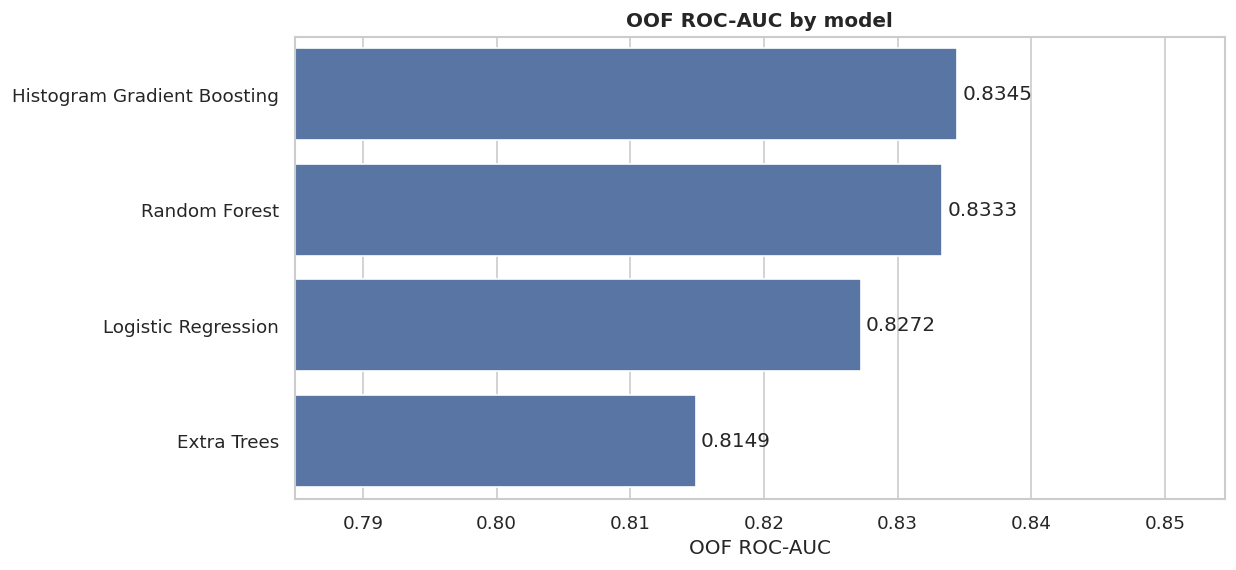

In [ ]:
comparison_rows = []
for model_name, prediction in oof_predictions.items():
    model_folds = fold_results.query("model == @model_name")
    comparison_rows.append({
        "model": model_name,
        "fold_auc_mean": model_folds["roc_auc"].mean(),
        "fold_auc_std": model_folds["roc_auc"].std(ddof=1),
        "oof_roc_auc": roc_auc_score(y, prediction),
        "oof_pr_auc": average_precision_score(y, prediction),
        "oof_log_loss": log_loss(y, prediction),
        "oof_brier_score": brier_score_loss(y, prediction),
        "total_cv_seconds": model_folds["seconds"].sum(),
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("oof_roc_auc", ascending=False)
    .reset_index(drop=True)
)
display(model_comparison.style.format({
    "fold_auc_mean": "{:.5f}", "fold_auc_std": "{:.5f}",
    "oof_roc_auc": "{:.5f}", "oof_pr_auc": "{:.5f}",
    "oof_log_loss": "{:.5f}", "oof_brier_score": "{:.5f}",
    "total_cv_seconds": "{:.1f}",
}).highlight_max(subset=["oof_roc_auc"], color="#c6efce"))

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=model_comparison, x="oof_roc_auc", y="model", color=sns.color_palette()[0])
ax.set(title="OOF ROC-AUC by model", xlabel="OOF ROC-AUC", ylabel="")
ax.set_xlim(max(0.5, model_comparison.oof_roc_auc.min() - 0.03), min(1.0, model_comparison.oof_roc_auc.max() + 0.02))
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
plt.show()

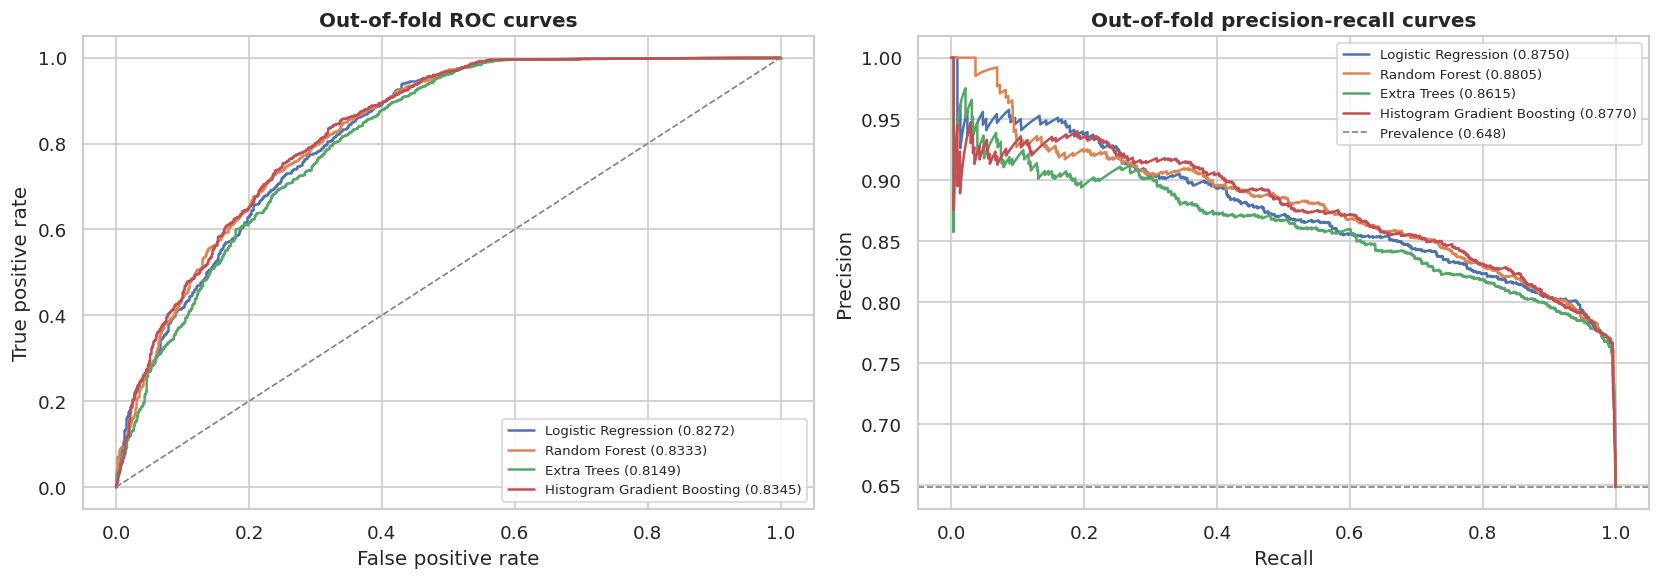

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, prediction in oof_predictions.items():
    fpr, tpr, _ = roc_curve(y, prediction)
    axes[0].plot(fpr, tpr, label=f"{model_name} ({roc_auc_score(y, prediction):.4f})")
    precision, recall, _ = precision_recall_curve(y, prediction)
    axes[1].plot(recall, precision, label=f"{model_name} ({average_precision_score(y, prediction):.4f})")

axes[0].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
axes[0].set(title="Out-of-fold ROC curves", xlabel="False positive rate", ylabel="True positive rate")
axes[1].axhline(y.mean(), linestyle="--", color="gray", linewidth=1, label=f"Prevalence ({y.mean():.3f})")
axes[1].set(title="Out-of-fold precision-recall curves", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## **7. Ensembling and Uncertainty** <a name="7-ensembling-and-uncertainty"></a>

Probability averaging is tested because independently biased models can rank observations better together. Only simple, auditable combinations of the strongest models are considered; no weights are optimized against the same OOF predictions used for evaluation.

The selected candidate is the model or simple ensemble with the highest OOF ROC-AUC. Because candidate selection uses the validation results, the reported number remains an internal estimate—not a guarantee of leaderboard performance.

### 7.1 Ensemble Selection Strategy

In [ ]:
ordered_models = model_comparison["model"].tolist()

candidate_predictions = {name: oof_predictions[name] for name in ordered_models}
candidate_members = {name: [name] for name in ordered_models}

for size in [2, 3, len(ordered_models)]:
    members = ordered_models[:size]
    candidate_name = f"Probability average (top {size})"
    candidate_predictions[candidate_name] = np.mean([oof_predictions[m] for m in members], axis=0)
    candidate_members[candidate_name] = members

# Rank averaging is reported as a robustness diagnostic, but not used for final
# probability selection because rank values are not calibrated probabilities.
rank_members = ordered_models[:2]
rank_average = np.mean(
    [pd.Series(oof_predictions[m]).rank(method="average", pct=True).to_numpy() for m in rank_members],
    axis=0,
)

selection_table = pd.DataFrame([
    {
        "candidate": name,
        "members": " + ".join(candidate_members[name]),
        "oof_roc_auc": roc_auc_score(y, pred),
        "oof_pr_auc": average_precision_score(y, pred),
        "oof_log_loss": log_loss(y, pred),
        "oof_brier_score": brier_score_loss(y, pred),
    }
    for name, pred in candidate_predictions.items()
]).sort_values("oof_roc_auc", ascending=False).reset_index(drop=True)

selected_candidate = selection_table.loc[0, "candidate"]
selected_members = candidate_members[selected_candidate]
selected_oof = candidate_predictions[selected_candidate]

display(selection_table.style.format({
    "oof_roc_auc": "{:.5f}", "oof_pr_auc": "{:.5f}",
    "oof_log_loss": "{:.5f}", "oof_brier_score": "{:.5f}",
}).highlight_max(subset=["oof_roc_auc"], color="#c6efce"))
print(f"Rank-average diagnostic AUC (top 2): {roc_auc_score(y, rank_average):.5f}")
print(f"Selected candidate: {selected_candidate}")
print(f"Final members: {selected_members}")

,candidate,members,oof_roc_auc,oof_pr_auc,oof_log_loss,oof_brier_score
0,Probability average (top 3),Histogram Gradient Boosting + Random Forest + Logistic Regression,0.83943,0.88753,0.43192,0.13851
1,Probability average (top 2),Histogram Gradient Boosting + Random Forest,0.83756,0.88466,0.43817,0.14027
2,Probability average (top 4),Histogram Gradient Boosting + Random Forest + Logistic Regression + Extra Trees,0.83555,0.88314,0.43348,0.13950
3,Histogram Gradient Boosting,Histogram Gradient Boosting,0.83445,0.87698,0.43421,0.13961
4,Random Forest,Random Forest,0.83335,0.88051,0.45836,0.14706
5,Logistic Regression,Logistic Regression,0.82722,0.87503,0.43727,0.14110
6,Extra Trees,Extra Trees,0.81491,0.86151,0.50794,0.14905


Rank-average diagnostic AUC (top 2): 0.83746
Selected candidate: Probability average (top 3)
Final members: ['Histogram Gradient Boosting', 'Random Forest', 'Logistic Regression']


### 7.2 Bootstrap Confidence Intervals

Selected OOF ROC-AUC: 0.83943
Bootstrap 95% CI:      [0.82317, 0.85443]


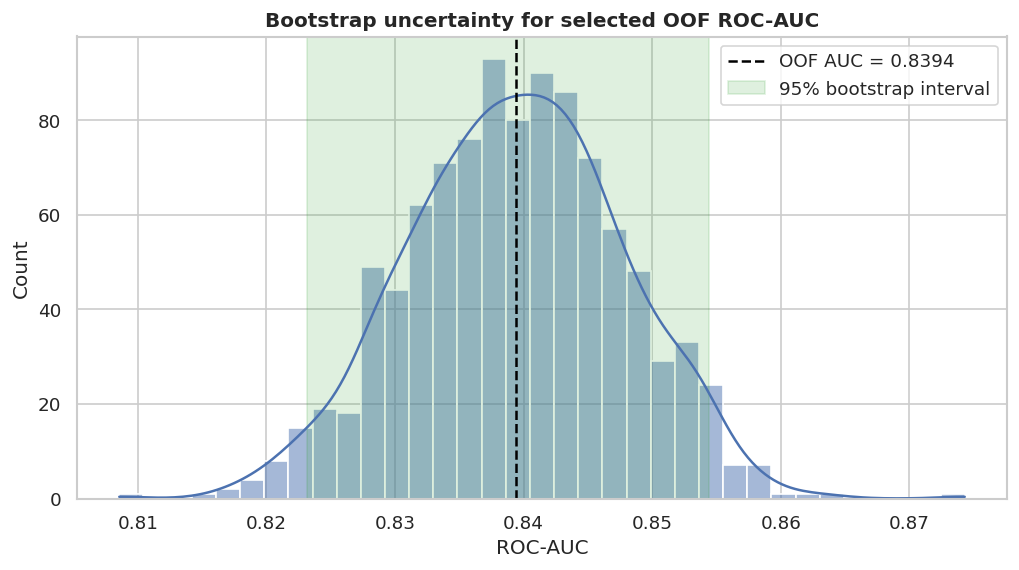

In [ ]:
def bootstrap_auc_ci(y_true, probabilities, n_bootstrap=1000, confidence=0.95, seed=SEED):
    rng = np.random.default_rng(seed)
    y_array = np.asarray(y_true)
    p_array = np.asarray(probabilities)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y_array), len(y_array))
        if np.unique(y_array[idx]).size == 2:
            scores.append(roc_auc_score(y_array[idx], p_array[idx]))
    alpha = (1 - confidence) / 2
    lower, upper = np.quantile(scores, [alpha, 1 - alpha])
    return float(lower), float(upper), np.asarray(scores)


ci_low, ci_high, bootstrap_scores = bootstrap_auc_ci(y, selected_oof)
selected_auc = roc_auc_score(y, selected_oof)

print(f"Selected OOF ROC-AUC: {selected_auc:.5f}")
print(f"Bootstrap 95% CI:      [{ci_low:.5f}, {ci_high:.5f}]")

ax = sns.histplot(bootstrap_scores, bins=35, kde=True)
ax.axvline(selected_auc, color="black", linestyle="--", label=f"OOF AUC = {selected_auc:.4f}")
ax.axvspan(ci_low, ci_high, color="tab:green", alpha=0.15, label="95% bootstrap interval")
ax.set(title="Bootstrap uncertainty for selected OOF ROC-AUC", xlabel="ROC-AUC")
ax.legend()
plt.show()

## **8. Diagnostics and Interpretation** <a name="8-diagnostics-and-interpretation"></a>

ROC-AUC measures ranking, but a professional evaluation should also inspect calibration, subgroup stability, and individual errors. Permutation importance is computed on the first held-out fold using the strongest single model, so the diagnostic is evaluated on data unseen during that fit.

### 8.1 Calibration and Prediction Distribution

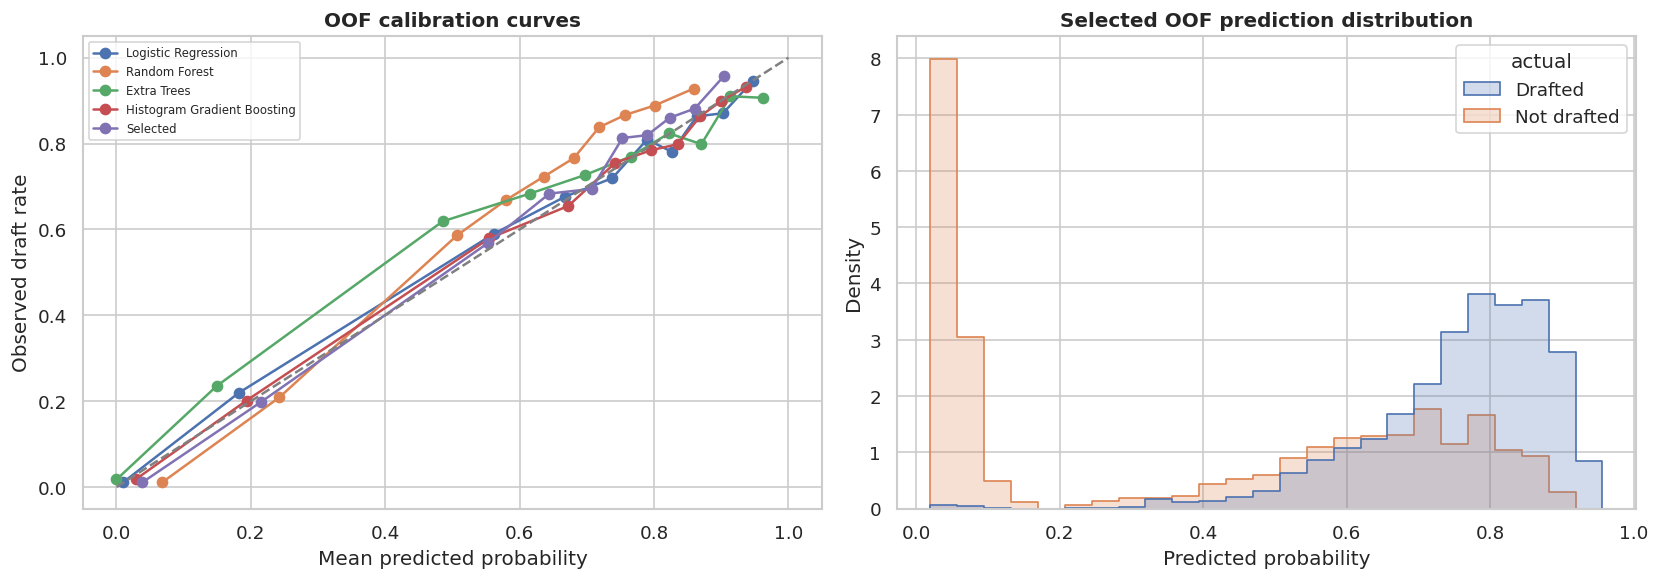

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, prediction in {**oof_predictions, "Selected": selected_oof}.items():
    fraction_positive, mean_predicted = calibration_curve(y, prediction, n_bins=10, strategy="quantile")
    axes[0].plot(mean_predicted, fraction_positive, marker="o", label=model_name)

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(title="OOF calibration curves", xlabel="Mean predicted probability", ylabel="Observed draft rate")
axes[0].legend(fontsize=7)

plot_frame = pd.DataFrame({"predicted_probability": selected_oof, "actual": y.map({0: "Not drafted", 1: "Drafted"})})
sns.histplot(
    data=plot_frame, x="predicted_probability", hue="actual",
    bins=25, stat="density", common_norm=False, element="step", ax=axes[1]
)
axes[1].set(title="Selected OOF prediction distribution", xlabel="Predicted probability")
plt.tight_layout()
plt.show()

### 8.2 Permutation Importance

,feature,importance_mean,importance_std
0,AGE_MISSING,0.1876,0.0213
1,SPEED_SCORE,0.0581,0.0081
2,Weight,0.0204,0.0047
3,Age,0.0151,0.0056
4,Sprint_40yd,0.0143,0.0070
5,Position,0.0060,0.0033
6,Bench_Press_Reps,0.0047,0.0014
7,Height,0.0041,0.0016
8,Player_Type,0.0022,0.0023
9,Position_Type,0.0018,0.0008


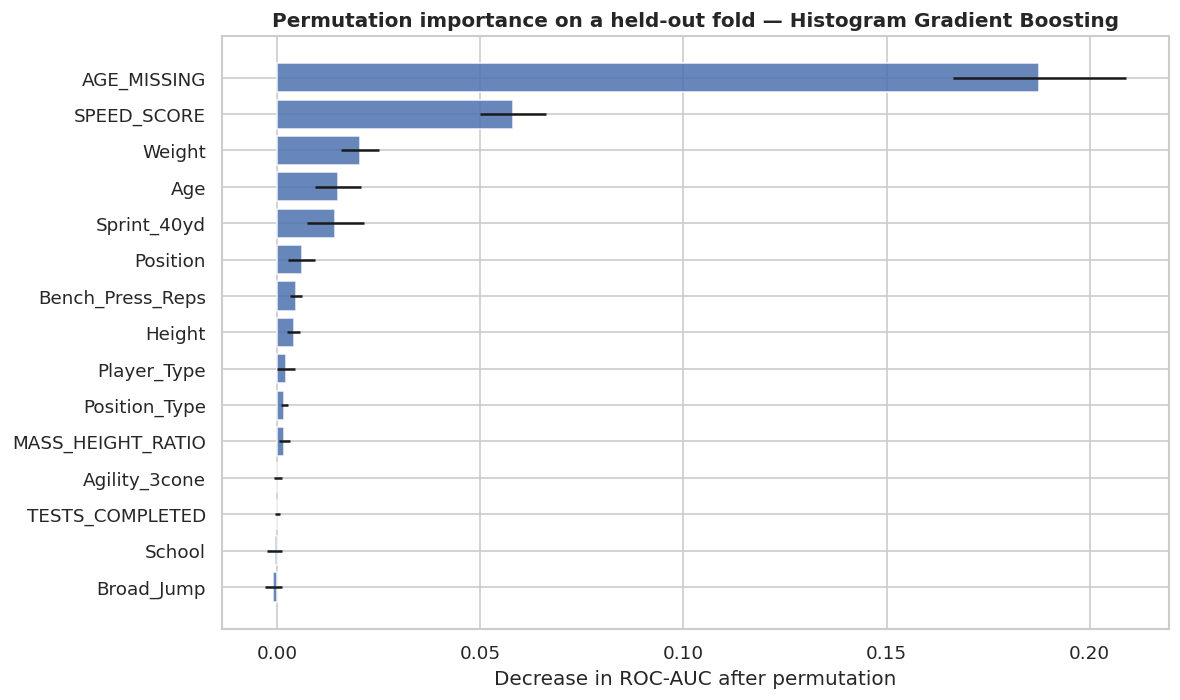

In [ ]:
best_single_name = ordered_models[0]
importance_train_idx, importance_valid_idx = next(cv.split(X, y))
importance_model = clone(models[best_single_name])
importance_model.fit(X.iloc[importance_train_idx], y.iloc[importance_train_idx])

permutation = permutation_importance(
    importance_model,
    X.iloc[importance_valid_idx],
    y.iloc[importance_valid_idx],
    scoring="roc_auc",
    n_repeats=8,
    random_state=SEED,
    n_jobs=1,
)

feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance.head(15))

top_importance = feature_importance.head(15).sort_values("importance_mean")
plt.figure(figsize=(10, 6))
plt.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
    alpha=0.85,
)
plt.title(f"Permutation importance on a held-out fold — {best_single_name}")
plt.xlabel("Decrease in ROC-AUC after permutation")
plt.tight_layout()
plt.show()

### 8.3 Subgroup and Error Analysis

In [ ]:
error_analysis = train[[ID_COL, TARGET, "Year", "Age", "School", "Position"]].copy()
error_analysis["oof_probability"] = selected_oof
error_analysis["absolute_error"] = np.abs(error_analysis[TARGET] - error_analysis["oof_probability"])
error_analysis["age_missing"] = error_analysis["Age"].isna()

subgroup_performance = []
for age_missing, group in error_analysis.groupby("age_missing"):
    subgroup_performance.append({
        "segment": "Age missing" if age_missing else "Age available",
        "rows": len(group),
        "draft_rate": group[TARGET].mean(),
        "roc_auc": roc_auc_score(group[TARGET], group["oof_probability"]) if group[TARGET].nunique() == 2 else np.nan,
        "brier_score": brier_score_loss(group[TARGET], group["oof_probability"]),
    })

display(pd.DataFrame(subgroup_performance).style.format({
    "draft_rate": "{:.2%}", "roc_auc": "{:.5f}", "brier_score": "{:.5f}"
}))

print("Most confident OOF false positives:")
display(
    error_analysis.query(f"{TARGET} == 0")
    .nlargest(10, "oof_probability")
    .drop(columns="absolute_error")
)

print("Most confident OOF false negatives:")
display(
    error_analysis.query(f"{TARGET} == 1")
    .nsmallest(10, "oof_probability")
    .drop(columns="absolute_error")
)

,segment,rows,draft_rate,roc_auc,brier_score
0,Age available,2346,76.51%,0.71944,0.16065
1,Age missing,435,1.84%,0.63642,0.01914


Most confident OOF false positives:


,Id,Drafted,Year,Age,School,Position,oof_probability,age_missing
801,801,0.0000,2013,21.0000,Arkansas,OG,0.9135,False
2693,2693,0.0000,2018,23.0000,Northwestern,S,0.9081,False
1934,1934,0.0000,2012,22.0000,Stanford,WR,0.9064,False
845,845,0.0000,2010,21.0000,Fresno St.,RB,0.9046,False
1376,1376,0.0000,2010,21.0000,Temple,OLB,0.8982,False
1844,1844,0.0000,2018,22.0000,Florida St.,OLB,0.8960,False
1797,1797,0.0000,2018,20.0000,Texas,CB,0.8922,False
2067,2067,0.0000,2013,21.0000,Georgia,DT,0.8918,False
2043,2043,0.0000,2009,21.0000,Wisconsin,OLB,0.8820,False
1675,1675,0.0000,2017,22.0000,Washington,TE,0.8818,False


Most confident OOF false negatives:


,Id,Drafted,Year,Age,School,Position,oof_probability,age_missing
2280,2280,1.0000,2010,NaN,Virginia Tech,P,0.0275,True
2392,2392,1.0000,2012,NaN,California,DE,0.0382,True
490,490,1.0000,2009,NaN,Michigan,DT,0.0522,True
706,706,1.0000,2009,NaN,Missouri,DE,0.0546,True
2574,2574,1.0000,2015,NaN,Alabama,OLB,0.0609,True
1620,1620,1.0000,2010,NaN,Florida St.,SS,0.0624,True
2681,2681,1.0000,2009,NaN,LSU,WR,0.0859,True
2136,2136,1.0000,2009,NaN,Ohio St.,OLB,0.1308,True
643,643,1.0000,2011,23.0000,Nebraska,K,0.2355,False
146,146,1.0000,2016,22.0000,Syracuse,P,0.2777,False


## **9. Final Training and Submission** <a name="9-final-training-and-submission"></a>

Each selected member is refitted on all training rows. Their test probabilities are averaged using the same rule chosen from OOF predictions. The submission is then validated for schema, row order, missing values, numeric range, and non-constant predictions.

### 9.1 Final Refit and Submission Generation

In [ ]:
fitted_final_models = {}
test_member_predictions = []

for model_name in selected_members:
    print(f"Fitting final {model_name}...")
    final_model = clone(models[model_name])
    final_model.fit(X, y)
    fitted_final_models[model_name] = final_model
    test_member_predictions.append(final_model.predict_proba(X_test)[:, 1])

test_probabilities = np.mean(test_member_predictions, axis=0)

submission = sample_submission.copy()
submission[TARGET] = test_probabilities

assert submission.shape == sample_submission.shape
assert submission.columns.tolist() == [ID_COL, TARGET]
assert submission[ID_COL].tolist() == test[ID_COL].tolist()
assert submission[TARGET].notna().all()
assert np.isfinite(submission[TARGET]).all()
assert submission[TARGET].between(0, 1).all()
assert submission[TARGET].nunique() > 1

submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

print(f"Saved: {submission_path.resolve()}")
print(f"Rows: {len(submission):,}")
print(f"Probability range: [{submission[TARGET].min():.6f}, {submission[TARGET].max():.6f}]")
display(submission.head(10))

Fitting final Histogram Gradient Boosting...
Fitting final Random Forest...
Fitting final Logistic Regression...
Saved: /content/outputs/submission.csv
Rows: 696
Probability range: [0.020856, 0.942183]


,Id,Drafted
0,2781,0.5625
1,2782,0.8215
2,2783,0.8842
3,2784,0.8537
4,2785,0.7958
5,2786,0.5546
6,2787,0.0518
7,2788,0.5288
8,2789,0.7672
9,2790,0.8661


### 9.2 Exporting Reproducibility Artifacts

In [ ]:
model_comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
fold_results.to_csv(OUTPUT_DIR / "fold_results.csv", index=False)
feature_importance.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

oof_export = train[[ID_COL, TARGET]].copy()
for model_name, prediction in oof_predictions.items():
    safe_name = model_name.lower().replace(" ", "_")
    oof_export[f"oof_{safe_name}"] = prediction
oof_export["oof_selected"] = selected_oof
oof_export.to_csv(OUTPUT_DIR / "oof_predictions.csv", index=False)

run_summary = {
    "seed": SEED,
    "cv_folds": N_SPLITS,
    "selected_candidate": selected_candidate,
    "selected_members": selected_members,
    "oof_roc_auc": selected_auc,
    "bootstrap_95_ci": [ci_low, ci_high],
    "train_shape": list(train.shape),
    "test_shape": list(test.shape),
}
with open(OUTPUT_DIR / "run_summary.json", "w", encoding="utf-8") as file:
    json.dump(run_summary, file, indent=2)

print("Reproducibility artifacts:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"- {path.name} ({path.stat().st_size:,} bytes)")

Reproducibility artifacts:
- feature_importance.csv (1,062 bytes)
- fold_results.csv (2,373 bytes)
- model_comparison.csv (712 bytes)
- oof_predictions.csv (285,861 bytes)
- run_summary.json (391 bytes)
- submission.csv (16,805 bytes)


## **10. Conclusions and Next Experiments** <a name="10-conclusions-and-next-experiments"></a>

### What this notebook establishes

- A reproducible, leakage-safe comparison across four model families.
- Selection based on unseen OOF predictions under a shared validation scheme.
- A conservative ensemble policy without OOF-optimized weights.
- Diagnostics covering discrimination, calibration, uncertainty, feature importance, and subgroup errors.
- A fully automated, validated competition submission.

### Responsible interpretation

The unusually strong association between missing age and the target may reflect the data-collection process. It can improve in-distribution validation while remaining vulnerable to train-test or public-private leaderboard shift. The subgroup diagnostics should therefore be reviewed alongside the aggregate AUC.

### High-value next experiments

1. Repeat cross-validation across several seeds to assess ranking stability.
2. Test feature ablations, especially `AGE_MISSING` and `SPEED_SCORE`.
3. Tune the strongest model with nested or carefully separated validation.
4. Compare time-aware validation by `Year` if the test period represents future seasons.
5. Consider CatBoost or LightGBM only if the runtime permits, keeping preprocessing inside each fold.

---

**Reproducibility note:** Re-running all cells regenerates every reported metric and output file from the three supplied CSV files.